In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# Data Loading

In [2]:
df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

In [3]:
import warnings 
warnings.filterwarnings("ignore")

# Milestone 1

In [4]:
# #What is the shape of the training dataset?
# df.shape

In [5]:
# #How many columns are present in the test dataset?
# df.shape[1]

In [6]:
# #How many columns in the training dataset have object data type?
# (df.dtypes=='object').sum()

In [7]:
# #How many numerical columns are present in the training dataset?
# (df.select_dtypes(include=['number'])).columns

In [8]:
# #Which of the following columns is of boolean type
# (df.select_dtypes(include=['bool'])).columns

In [9]:
# #Which of the following columns have missing values?
# df.isna().sum().sort_values(ascending=False)

In [10]:
# #How many distinct target classes are present in the dataset?
# df['label'].unique()

In [11]:
# #What percentage of the dataset approximately belongs to label 0?
# df['label'].value_counts(normalize=True)[0]

In [12]:
# #What is the median number of upvotes per comment?
# df['upvote'].median()

In [13]:
# #Which numerical feature shows the largest maximum value?
# df.select_dtypes(include=['number']).max()

In [14]:
# #What is the minimum value of if_2?
# df['if_2'].min()

# Milestone 2

In [15]:
#In the context of text preprocessing for NLP, which condition must be checked in addition 
# to NaN values when assessing missingness in the comment column of train.csv?

# Presence of empty or whitespace-only strings

In [16]:
# #Convert the created_date column into datetime objects. Identify the month that occurs 
# #the most number of times in the dataset and enter the answer as a lowercase string

# df['created_date'] = pd.to_datetime(df['created_date'])
# df['posted_month'] = df['created_date'].dt.month_name().str.lower()
# most_common_month = df["posted_month"].value_counts().idxmax()
# print(most_common_month)

In [17]:
# #Create a new feature called total_emoticons by calculating the sum of emoticon_1, emoticon_2, and emoticon_3 for each row. 
# # What is the maximum value observed in this new feature across the entire dataset?

# df['total_emoticons'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
# max_total = df['total_emoticons'].max()
# print(max_total)

In [18]:
# # Calculate the median character length (including spaces) of the comment column for all entries
# # where label is equal to 3. (Note: Treat any missing comments as empty strings).
# df['comment'] = df['comment'].fillna("")
# label_3 = df[df['label'] == 3]['comment']
# median = label_3.str.len().median()
# print(median)

In [19]:
# # If you apply Min-Max Scaling to the upvote column to normalize it between the range [0, 1], 
# # what would be the resulting scaled value for an observation that originally had exactly 10 upvotes?
# min_u = df['upvote'].min()
# max_u = df['upvote'].max()
# scaled_value = (10-min_u)/(max_u-min_u)
# print(scaled_value)

In [20]:
# # What is the average word count (number of words separated by whitespace) for comments 
# # that are assigned a label of 1? (Round your answer to 2 decimal places).

# label1_c = df[df['label'] == 1]['comment']
# count = label1_c.str.split().str.len()
# avg_w = round(count.mean(), 2)
# print(avg_w)

In [21]:
# # How many comments in the entire dataset contain the substring "Trump"? The search should be case-insensitive.
# trump_c = df['comment'].str.contains("trump", case=False).sum()
# print(trump_c)

In [22]:
# # Take the comment at the very first row (index 0).
# # - Remove all punctuation.
# # - Consider the following words as stop words and remove the same :  
# # ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
# # How many words are left in the text after these two operations?

# stop_word =  ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 
#               'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 
#               'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 
#               'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
# ch = df.iloc[0]['comment']
# punch = ''.join([c for c in ch if not c.isalpha() and not c.isspace()])
# punch_set = set(punch)
# for p in punch_set:
#     ch = ch.replace(p, "")
# word = ch.lower().split()
# filtered_ch = [w for w in word if w not in stop_word]
# count_word = len(filtered_ch)
# print(count_word)

In [23]:
# # Convert all the text in comment column to lowercase and tokenizing using whitespace. 
# # Compute the total number of unique tokens in the dataset and enter the value

# tokens = df['comment'].str.lower().str.split()
# all_words = tokens.explode()
# uniq_w_len = len(set(all_words))
# print(uniq_w_len) 

In [24]:
 # Apply the TfidfVectorizer to the comment column of train.csv with stop_words as "english", min_df as 5 and ngram_range as (1,2).
# # How many TF-IDF features are generated using this configuration? 


# from sklearn.feature_extraction.text import TfidfVectorizer
# vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=5, stop_words='english')
# vectorizer.fit_transform(df['comment'])
# x = len(vectorizer.get_feature_names_out())
# print(x)

# Milestone 3

In [25]:
# X = df.drop(['label'], axis=1)
# y = df['label']

In [26]:
# # Split the train dataset using train_test_split with random_state=42 such that 80% is training data 
# # and remaining 20% is validation data. store the data as X_train, X_val, y_train, y_val. Lets say training data (X_train) has shape (a,b) where 
# # a is number of rows and b is the number of features, similarly validation set (X_val) has shape (c,d) where c is the number of rows and d is the number of features. what will be the value of a + c ?
# from sklearn.model_selection import train_test_split
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# print("X_train shape:", X_train.shape)
# print("X_val shape:", X_val.shape)
# print("y_train shape:", y_train.shape)
# print("y_val shape:", y_val.shape)
# a = X_train.shape[0]
# c = X_val.shape[0]
# print("a + c = ", a+c)

In [27]:
# # 'After converting created_date to a datetime object and extracting the day, month, and year for 
# # your X_train and X_val created in the first question, identify the most frequently occurring month 
# # across all years in X_train. Which month is it?'
# X_train['created_date'] = pd.to_datetime(X_train['created_date'])
# X_val['created_date'] = pd.to_datetime(X_val['created_date'])

# X_train['day'] = X_train['created_date'].dt.day
# X_train['month'] = X_train['created_date'].dt.month
# X_train['year'] = X_train['created_date'].dt.year

# X_val['day'] = X_val['created_date'].dt.day
# X_val['month'] = X_val['created_date'].dt.month
# X_val['year'] = X_val['created_date'].dt.year
# mostfreq_month = X_train['month'].value_counts().idxmax
# print(mostfreq_month)

In [28]:
# # Impute the null values of categorical features with the value 'none'. Encode only religion', 'gender', 'race' 
# # features using one hot encoding, setting handle_unknown='ignore'. Make sure the output is a pandas dataframe. 
# # Let's say the shape of X_train after imputing is (a,b), what is the value of b ?
# # Note: make sure to transform X_val as well using one hot encoding.

# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

# X_train_raw = X_train.copy()
# X_val_raw = X_val.copy()

# cat_cols= ['religion', 'gender', 'race']
# cat_pipe = Pipeline([ ('imputer' , SimpleImputer(strategy='constant', fill_value='none')),
# ('encoder', OneHotEncoder(handle_unknown='ignore'))])

# preprocessor = ColumnTransformer([
#     ('cat', cat_pipe, cat_cols)
# ], remainder='passthrough')

# X_train_pro = preprocessor.fit_transform(X_train)
# X_val_pro = preprocessor.transform(X_val)

# X_train = pd.DataFrame(X_train_pro, columns=preprocessor.get_feature_names_out())
# X_val = pd.DataFrame(X_val_pro, columns=preprocessor.get_feature_names_out())

# b = X_train.shape[1]
#print(b)

In [29]:
# # Apply CountVectorizer to the column comment of X_train and X_val obtained in previous questions, 
# # what is the sum of the counts for the document at index 1 (the second row) of the transformed X_train sparse matrix?
# # Note: Please ensure to transform X_val as well.

# from sklearn.feature_extraction.text import CountVectorizer
# vectorizer = CountVectorizer()
# X_train_c = vectorizer.fit_transform(X_train_raw['comment'])
# X_val_c = vectorizer.transform(X_val_raw['comment'])
# row_sum = X_train_c[1].sum()
# print(row_sum)

In [30]:
# # Convert 'disability' feature into integer type, with True being mapped to 1 and False mapped to 0. 
# # What is the sum of all the 'disability values in X_train and X_val after the transformation?

# X_train['disability'] = X_train_raw['disability'].astype(int)
# X_val['disability'] = X_val_raw['disability'].astype(int)

# total_sum = X_train['disability'].sum() + X_val['disability'].sum()
# print(total_sum)

In [31]:
# # Scale the numeric features using StandardScaler. What are the number of features seen during fit for X_train? 
# # Ensure that you drop all datetime columns first.
# from sklearn.preprocessing import StandardScaler

# datetime_cols = X_train_raw.select_dtypes(include=['datetime64']).columns
# X_train_num = X_train_raw.drop(columns=datetime_cols)
# X_val_num = X_val_raw.drop(columns=datetime_cols)
# num_cols = X_train_num.select_dtypes(include=["int64", 'float64']).columns

# scaler = StandardScaler()
# X_train_s = scaler.fit_transform(X_train_num[num_cols])
# X_val_s = scaler.fit_transform(X_val_num[num_cols])

# print(scaler.n_features_in_)

In [32]:
# next question

# X = df.drop(['label'], axis=1)
# y = df['label']

# from sklearn.model_selection import train_test_split
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# X_train['created_date'] = pd.to_datetime(X_train['created_date'])
# X_val['created_date'] = pd.to_datetime(X_val['created_date'])

# X_train['day'] = X_train['created_date'].dt.day
# X_train['month'] = X_train['created_date'].dt.month
# X_train['year'] = X_train['created_date'].dt.year
# X_train.drop(columns=['created_date'], inplace=True)

# X_val['day'] = X_val['created_date'].dt.day
# X_val['month'] = X_val['created_date'].dt.month
# X_val['year'] = X_val['created_date'].dt.year
# X_val.drop(columns=['created_date'], inplace=True)

# text_col = 'comment'
# cat_cols = ['race', 'religion','gender']
# num_cols = [col for col in X_train.columns if col not in cat_cols + [text_col]]

# from sklearn.preprocessing import StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
# from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# num_pipe = Pipeline([
#     ('imputer', SimpleImputer(strategy='median')),
#     ('absolute', FunctionTransformer(np.abs))
# ])

# cat_pipe = Pipeline([
#     ('imputer', SimpleImputer(strategy='most_frequent')),
#     ('onehot',  OneHotEncoder(handle_unknown='ignore'))
# ])

# text_pipe = Pipeline([
#     ('imputer', SimpleImputer(strategy='constant', fill_value='')),
#     ('flatten', FunctionTransformer(lambda x: x.ravel(), validate=False)),
#     ('tfidf', TfidfVectorizer(stop_words='english'))
# ])

# preprocessor = ColumnTransformer([
#     ('num', num_pipe, num_cols),
#     ('cat', cat_pipe, cat_cols),
#     ('text', text_pipe, [text_col]),
# ])

# X_train_pro = preprocessor.fit_transform(X_train)
# X_val_pro = preprocessor.transform(X_val)

In [33]:
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import f1_score

# nb_model = MultinomialNB()
# nb_model.fit(X_train_pro, y_train)
# nb_train_pred = nb_model.predict(X_train_pro)
# nb_train_f1 = f1_score(y_train, nb_train_pred, average='macro')
# print(nb_train_f1)

In [34]:
# nb_model = MultinomialNB()
# nb_model.fit(X_train_pro, y_train)
# nb_val_pred = nb_model.predict(X_val_pro)
# nb_val_f1 = f1_score(y_val, nb_val_pred, average='macro')
# print(nb_val_f1)

In [35]:
# next question

# X = df.drop(['label'], axis=1)
# y = df['label']

# from sklearn.model_selection import train_test_split
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# X_train['created_date'] = pd.to_datetime(X_train['created_date'])
# X_val['created_date'] = pd.to_datetime(X_val['created_date'])

# X_train['day'] = X_train['created_date'].dt.day
# X_train['month'] = X_train['created_date'].dt.month
# X_train['year'] = X_train['created_date'].dt.year
# X_train['is_weekend'] = X_train['created_date'].dt.weekday.isin([5,6]).astype(int)
# X_train.drop(columns=['created_date'], inplace=True)


# X_val['day'] = X_val['created_date'].dt.day
# X_val['month'] = X_val['created_date'].dt.month
# X_val['year'] = X_val['created_date'].dt.year
# X_val['is_weekend'] = X_val['created_date'].dt.weekday.isin([5,6]).astype(int)
# X_val.drop(columns=['created_date'], inplace=True)

# text_col = 'comment'
# cat_cols = ['race', 'religion','gender', 'is_weekend']
# num_cols = [col for col in X_train.columns if col not in cat_cols + [text_col]]
# from sklearn.preprocessing import StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
# from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# num_pipe = Pipeline([
#     ('imputer', SimpleImputer(strategy='median')),
#     ('absolute', FunctionTransformer(np.abs))
# ])

# cat_pipe = Pipeline([
#     ('imputer', SimpleImputer(strategy='most_frequent')),
#     ('onehot',  OneHotEncoder(handle_unknown='ignore'))
# ])

# text_pipe = Pipeline([
#     ('imputer', SimpleImputer(strategy='constant', fill_value='')),
#     ('flatten', FunctionTransformer(lambda x: x.ravel(), validate=False)),
#     ('tfidf', TfidfVectorizer(stop_words='english'))
# ])

# preprocessor = ColumnTransformer([
#     ('num', num_pipe, num_cols),
#     ('cat', cat_pipe, cat_cols),
#     ('text', text_pipe, [text_col]),
# ])
# X_train_pro = preprocessor.fit_transform(X_train)
# X_val_pro = preprocessor.transform(X_val)

In [36]:
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import f1_score

# nb_model = MultinomialNB()
# nb_model.fit(X_train_pro, y_train)
# nb_train_pred = nb_model.predict(X_train_pro)
# nb_train_f1 = round(f1_score(y_train, nb_train_pred, average='macro'), 4)
# print(nb_train_f1)

In [37]:
# nb_model = MultinomialNB()
# nb_model.fit(X_train_pro, y_train)
# nb_val_pred = nb_model.predict(X_val_pro)
# nb_val_f1 = f1_score(y_val, nb_val_pred, average='macro')
# print(nb_val_f1)

# Milestone 4

In [38]:
# # Q1) Load the dataset and fill the NaN values in comment column with empty string then follow the below steps
# # A) Split the dataset after doing above step using train_test_split into 60% train and 40% validation. Keep random_state = 2306 and set stratify to the target variable (y).
# # After splitting, compute the class-wise counts of the training labels and validation labels using value_counts().
# # Before storing the counts, sort the class labels in ascending order to ensure consistent ordering. Store the resulting counts as NumPy arrays.

# df['comment'] = df['comment'].fillna("")

# X = df.drop(['label'], axis=1)
# y = df['label']

# from sklearn.model_selection import train_test_split
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=2306, stratify=y)

# train_count = y_train.value_counts().sort_index().to_numpy()
# val_count = y_val.value_counts().sort_index().to_numpy()

# print("train_counts:", train_count)
# print("val_counts:", val_count)

In [39]:
# # B) Load the same dataset and split it again using train_test_split, keeping all configurations the same as in Part A (60% train and 40% validation, random_state = 2306), but set stratify = None.
# # Again, compute the sorted class-wise counts of the training labels and validation labels and store them as NumPy arrays.

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=2306, stratify=None)
# train_count_n = y_train.value_counts().sort_index().to_numpy()
# val_count_n = y_val.value_counts().sort_index().to_numpy()

# print("train_counts:", train_count_n)
# print("val_counts:", val_count_n)

In [40]:
# # C) Validation Distribution Difference
# # Using the validation label counts from Part A (stratified) and Part B (non-stratified)
# # Convert both validation class count arrays into proportions by dividing each count by the total number of validation samples.
# # Make sure the class labels remain in ascending order (same order as before).
# # For each class, compute the absolute difference between the two proportions.
# # Find the maximum of these absolute differences.

# val_proportions = val_count / val_count.sum()
# val_proportions_n = val_count_n / val_count_n.sum()

# diff = np.abs(val_proportions - val_proportions_n)
# max_diff = diff.max()
# print(max_diff)

In [41]:
# # Q2) Use the stratified train–validation split obtained in Q1 (60% train, 40% validation, random_state=2306, stratify=y).
# # All preprocessing objects must be fit only on the training data and then used to transform both training and validation sets.
# # Step1: Column Removal
# # From both x_train and x_test:
# # Drop the column "created_date".
# # Step 2: Separate Text Column
# # Before any tabular preprocessing, Extract the "comment" column:
# # text_x_train = x_train["comment"]
# # text_x_test = x_test["comment"]
# # Remove "comment" from both x_train and x_test.


# df['comment'] = df['comment'].fillna("")

# X = df.drop(['label'], axis=1)
# y = df['label']

# from sklearn.model_selection import train_test_split
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=2306, stratify=y)

# X_train = X_train.drop(columns=['created_date'])
# X_val = X_val.drop(columns=['created_date'])

# text_X_train = X_train["comment"]
# text_X_val = X_val["comment"]

# X_train = X_train.drop(columns=['comment'])
# X_val = X_val.drop(columns=['comment'])

In [42]:
# # Step 3: Tabular Preprocessing
# # Apply a ColumnTransformer with the following exact configuration:
# # Handling categorical columns
# # Categorical columns are ["race", "religion", "gender", "disability"]
# # Process the above categorical columns using below techniques :
# # SimpleImputer(strategy="most_frequent")
# # OneHotEncoder(handle_unknown="ignore", sparse_output=True)
# # Handling numerical columns
# # numerical columns are ["post_id", "emoticon_1", "emoticon_2", "emoticon_3",
# #  "upvote", "downvote", "if_1", "if_2"]
# # Process the above numerical columns using below techniques:
# # SimpleImputer(strategy="mean")
# # StandardScaler() (default parameters)
# # ColumnTransformer Settings
# # remainder="passthrough"
# # Fit only on x_train
# # Transform both x_train and x_test
# # Store the transformed matrices as:
# # x_train_tabular
# # x_test_tabular

# cat_cols =  ["race", "religion", "gender", "disability"]
# num_cols =  ["post_id", "emoticon_1", "emoticon_2", "emoticon_3","upvote", "downvote", "if_1", "if_2"]

# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.compose import ColumnTransformer

# cat_pipe = Pipeline([
#     ('imputer', SimpleImputer(strategy="most_frequent")),
#     ('onehot', OneHotEncoder(handle_unknown="ignore", sparse_output=True))
# ])

# num_pipe = Pipeline([
#     ('imputer', SimpleImputer(strategy="mean")),
#     ('scaler', StandardScaler())
# ])

# preprocessor = ColumnTransformer([
#     ('cat', cat_pipe, cat_cols),
#     ('num', num_pipe, num_cols)
# ], remainder="passthrough")

# X_train_tabular = preprocessor.fit_transform(X_train)
# X_val_tabular = preprocessor.transform(X_val)

In [43]:
# # Step 4: Text Cleaning
# # Define the following function exactly:
# # def normalize_text(text):
# #     text = re.sub(r'http\S+|www\S+', '', text)
# #     text = re.sub(r'\s+', '  ', text).strip()
# #     return text
# # apply it using .apply() on both text_x_train and text_x_test then store the result as text_x_train_norm, text_x_test_norm
# # Step 5: TF-IDF Vectorization
# # Use: TfidfVectorizer(stop_words="english", max_features=5000)
# # Fit only on text_x_train_norm and Transform both train and test text
# # Store as: tf_idf_train, tf_idf_test
# # Do not change any other parameters.
# # Step 6: Combine Features
# # Use: hstack to combine features in the following exact order:
# # X_train_final = hstack([x_train_tabular, tf_idf_train])
# # X_test_final = hstack([x_test_tabular, tf_idf_test])
# # The result must remain a sparse matrix.
# # Give the sum of all values of X_train_final, enter the answer upto 3 decimal places.
# # Note: handle the null values of comment column (if any) by replacing them with empty string to avoid errors.

# import re
# from sklearn.feature_extraction.text import TfidfVectorizer
# from scipy.sparse import hstack
# def normalize_text(text):
#     text = re.sub(r'http\S+|www\S+', '', text)
#     text = re.sub(r'\s+', '  ', text).strip()
#     return text
# text_X_train_norm = text_X_train.apply(normalize_text)
# text_X_val_norm   = text_X_val.apply(normalize_text)
# tf_idf = TfidfVectorizer(stop_words="english", max_features=5000)
# tf_idf_train = tf_idf.fit_transform(text_X_train_norm)
# tf_idf_val = tf_idf.transform(text_X_val_norm)

# X_train_final = hstack([X_train_tabular, tf_idf_train])
# X_val_final = hstack([X_val_tabular, tf_idf_val])

# total_sum = X_train_final.sum()
# print(round(total_sum, 3))

In [44]:
# # This section is not a question, its the instruction for further questions
# # For all subsequent questions (Q3 onwards), reduce the feature space using TruncatedSVD(n_components=300, random_state=2306)
# # Instructions: 
# # Fit the TruncatedSVD only on X_train_final. 
# # Transform both  X_train_final and X_test_final
# # Store the transformed matrices as X_train_reduced and X_test_reduced.
# # Use X_train_reduced for all model training in the remaining questions.Do not refit SVD for each question. Do not change n_components.
# # This is just instruction and not the question, check the box once you read it carefully and prepare X_train_reduced, X_test_reduced.

# from sklearn.decomposition import TruncatedSVD
# svd = TruncatedSVD(n_components=300, random_state=2306)
# X_train_reduced = svd.fit_transform(X_train_final)
# X_val_reduced = svd.transform(X_val_final)
# print("X_train_reduced ", X_train_reduced )
# print("X_val_reduced ", X_val_reduced)

In [45]:
# # Use the preprocessed training data X_train_reduced.
# # Perform hyperparameter tuning for a RandomForestClassifier using RandomizedSearchCV.
# # Model Setup
# # Initialize the model as:
# # RandomForestClassifier(random_state=2306)
# # Do not manually set n_estimators or max_depth here, as they will be tuned.
# # Search only over the following parameter values:
# # n_estimators: [50, 100, 200]
# # max_depth: [5, 10, 15]
# # Do not include any other hyperparameters in the search.
# # RandomizedSearchCV Configuration is given below
# # n_iter = 5
# # cv = 3
# # random_state = 2306
# # n_jobs = -1
# # Do not manually specify the scoring parameter (use default).
# # After running: randomized_search.fit(X_train_reduced, y_train) 
# # Retrieve the best hyperparameters using: randomized_search.best_params_ 
# # Return the best value of n_estimators selected by RandomizedSearchCV. 
# # Return only the integer value.

# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import RandomizedSearchCV

# rf = RandomForestClassifier(random_state=2306)
# params = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [5, 10, 15]
# }

# rs = RandomizedSearchCV(estimator=rf, param_distributions=params, n_iter = 5,cv = 3,random_state = 2306, n_jobs = -1)
# rs.fit(X_train_reduced, y_train)
# best_params = rs.best_params_
# print(best_params['n_estimators'])

In [46]:
# # Use the same preprocessed training data (X_train_reduced, y_train).
# # Do not modify or recompute preprocessing.
# # Step 1: Train AdaBoost
# # Train an AdaBoostClassifier with the following exact parameters:
# # n_estimators = 50
# # random_state = 2306
# # Use all other parameters as default.
# # Note:
# # Do not manually set the algorithm parameter.
# # Use the default behavior of AdaBoostClassifier.
# # Fit the model on: X_train_reduced , y_train
# # Step 2: Extract Estimator Errors
# # After fitting, access: model.estimator_errors_
# # This returns a NumPy array of length 50 containing the error of each weak learner.
# # Step 3: Compute Variance
# # Compute the variance of the 50 estimator errors using:
# # np.var(model.estimator_errors_)
# # Important:
# # Use NumPy’s default variance computation.
# # Step 4: Final Answer
# # Return the variance rounded to 4 decimal places.

# from sklearn.ensemble import AdaBoostClassifier
# ada = AdaBoostClassifier(n_estimators = 50, random_state = 2306)
# ada.fit(X_train_reduced, y_train)
# errors = ada.estimator_errors_
# variance = np.var(errors)
# print(round(variance, 4))

In [47]:
# # Q5) Train a RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2306) using the preprocessed training data (X_train_reduced, y_train).
# # After fitting: Extract feature_importances_.
# # Give the index of the feature with the maximum importance value.
# # Note: If multiple features share the exact same maximum importance, return the smallest index.

# from sklearn.ensemble import RandomForestClassifier
# rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2306)
# rf_model.fit(X_train_reduced, y_train)
# imp = rf_model.feature_importances_
# max_index = np.argmax(imp)
# print(max_index)

In [48]:
# # Initialize an MLPClassifier with:
# # hidden_layer_sizes = (128, 64, 32)
# # activation = "relu"
# # random_state = 2306
# # Use the preprocessed training data (X_train_reduced , y_train).
# # Let N be the number of input features (i.e., X_train_reduced.shape[1]).
# # Compute the total number of weights (excluding biases) in the network.
# # Only count connection weights between layers. Do not include bias terms.
# # The network structure is: 
# # Input layer: N neurons
# # Hidden Layer 1: 128 neurons
# # Hidden Layer 2: 64 neurons
# # Hidden Layer 3: 32 neurons
# # Output Layer: 4 neurons
# # Use your actual value of N from X_train_reduced.
# # Return the final integer count of weights.
# from sklearn.neural_network import MLPClassifier
# mlp = MLPClassifier(hidden_layer_sizes = (128, 64, 32), activation = "relu", random_state = 2306)
# N = X_train_reduced.shape[1]
# hidden_layer_1 = N * 128
# hidden_layer_2 = N * 128 * 64
# hidden_layer_3 = N * 64 * 32
# output_layer = N * 32 * 4
# total_weight = hidden_layer_1 + hidden_layer_2 + hidden_layer_3 + output_layer
# print(total_weight)

In [49]:
# # Train the same MLP architecture defined in Q6 using the preprocessed training data (X_train_reduced, y_train) with the following additional parameters:
# # solver = "adam", max_iter = 5, batch_size = 32, random_state = 2306
# # Do not modify any other parameters (keep all others as default).
# # After training completes (i.e., after 5 iterations), access: model.loss_
# # This returns the final value of the loss function after the last iteration.
# # Return the value of model.loss_ rounded to 4 decimal places.

# from sklearn.neural_network import MLPClassifier
# mlp_model = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation = "relu", solver = "adam", max_iter = 5, batch_size = 32, random_state = 2306)
# mlp_model.fit(X_train_reduced, y_train)
# f_loss = mlp_model.loss_
# print(round(f_loss, 4))

In [50]:
# # Train two MLPs using the preprocessed training data (X_train_reduced, y_train) with hidden_layer_sizes=(100,), max_iter=5, and random_state=2306. use default values for other parameters unless specified.
# # • Model A: alpha=0.0001 (Default)
# # • Model B: alpha=1.0 (Strong Regularization)
# # Calculate the Macro F1 Score for both on the training set. What is the absolute difference between both the scores? (answer upto 4 decimal places).

# from sklearn.neural_network import MLPClassifier
# from sklearn.metrics import f1_score

# mlp_a = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5, random_state=2306)
# mlp_a.fit(X_train_reduced, y_train)

# mlp_b = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5, random_state=2306, alpha=1.0)
# mlp_b.fit(X_train_reduced, y_train)

# y_pred_a = mlp_a.predict(X_train_reduced)
# y_pred_b = mlp_b.predict(X_train_reduced)

# f1_a = f1_score(y_train, y_pred_a, average="macro")
# f1_b = f1_score(y_train, y_pred_b, average="macro")

# abs_diff = abs(f1_a - f1_b)
# print(round(abs_diff, 4))

In [51]:
# # Training the MLP model as per Q7, generate a confusion matrix for the validation set.
# # What is the sum of the off-diagonal elements (representing the total number of misclassified instances) divided by the total number of samples in the validation set? (Round to 4 decimal places). 

# from sklearn.metrics import confusion_matrix
# from sklearn.neural_network import MLPClassifier
# mlp_c = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation = "relu", solver = "adam", max_iter = 5, batch_size = 32, random_state = 2306)
# mlp_c.fit(X_train_reduced, y_train)
# y_val_pred = mlp_c.predict(X_val_reduced)
# c_matrix = confusion_matrix(y_val, y_val_pred)
# off_diag_sum = c_matrix.sum() - np.trace(c_matrix)
# total_samples = c_matrix.sum()
# misclassratio = off_diag_sum / total_samples
# print(round(misclassratio, 4))

# Milestone 5

In [52]:
# # You are given two datasets:
# # Training dataset: df(full training data)
# # Test dataset: test_df(test data) note: (we are not going to use test_df anywhere in below questions, but in project you will be required to process the test data as well, Due to this reason we have given task to perform preprocessing in test data given to you in competition as well.)
# # The target variable for the training dataset(df) is y.(extract it from training data and store it as y then drop the target column from training data)
# # Your task is to preprocess the data so that it can be used for model training.
# # Step 1: Datetime Feature Engineering
# # For both df and test_df: Convert the feature created_date to datetime format using pd.to_datetime().
# # Extract the following features from created_date:
# # year, month, hour
# # Add these as new features.
# # After extracting these features, drop the original created_date feature.
# # Step 2: Handle Missing Values
# # Perform the following preprocessing for both datasets (df and test_df):
# # Categorical Features
# # Fill missing values with "Unknown" for the following features: race, religion, gender
# # Text Feature: Replace missing values in the comment feature with an empty string "".
# # Boolean Feature: Convert the disability feature to integer type using .astype(int).

# y = df['label']
# df = df.drop(['label'], axis=1)

# df['created_date'] = pd.to_datetime(df['created_date'])
# df['hour'] = df['created_date'].dt.hour
# df['month'] = df['created_date'].dt.month
# df['year'] = df['created_date'].dt.year
# df.drop(columns=['created_date'], inplace=True)

# test_df['created_date'] = pd.to_datetime(test_df['created_date'])
# test_df['hour'] = test_df['created_date'].dt.hour
# test_df['month'] = test_df['created_date'].dt.month
# test_df['year'] = test_df['created_date'].dt.year
# test_df.drop(columns=['created_date'], inplace=True)

# df['gender'] = df['gender'].fillna('Unknown')
# df['race'] = df['race'].fillna('Unknown')
# df['religion'] = df['religion'].fillna('Unknown')
# df['comment'] = df['comment'].fillna('')

# test_df['gender'] = test_df['gender'].fillna('Unknown')
# test_df['race'] = test_df['race'].fillna('Unknown')
# test_df['religion'] = test_df['religion'].fillna('Unknown')
# test_df['comment'] = test_df['comment'].fillna('')

# df['disability'] = df['disability'].astype(int)
# test_df['disability'] = test_df['disability'].astype(int)

In [53]:
# # Step 3: Feature Transformation using ColumnTransformer:
# # Use ColumnTransformer to process the features as follows.
# # Text Feature --Apply: TfidfVectorizer(stop_words="english", max_features=5000) to the feature: comment
# # Categorical Features--
# # Apply: OneHotEncoder(drop="first", handle_unknown="ignore") to the following features:["race", "religion", "gender"]
# # Remaining features: All remaining features should be passed through unchanged using: remainder="passthrough"
# # This will keep numeric features such as:
# # year, month, hour, disability and other numeric features
# # Step 4: Transform the Data
# # Fit the ColumnTransformer only on the training dataset (df). Transform both datasets. Store the results as:
# # X = preprocessor.fit_transform(df)
# # X_test = preprocessor.transform(test_df)
# # Step 5: Create Train–Validation Split
# # Split the training features and labels(X,y) into training and validation sets using: train_test_split with the following parameters:
# # test_size = 0.2, random_state = 42
# # Store the outputs as: X_train, X_val, y_train, y_val
# # Final Output: After completing all steps, you should have the following variables ready for model training:
# # X_train, X_val, y_train, y_val, X_test
# # use this processed data for all the questions below.

# from sklearn.compose import ColumnTransformer
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.pipeline import Pipeline
# from sklearn.model_selection import train_test_split

# text_col = 'comment'
# cat_cols = ['race', 'religion', 'gender']

# cat_pipe = Pipeline([
#     ('onehot',  OneHotEncoder(drop="first", handle_unknown='ignore'))
# ])

# text_pipe = Pipeline([
#     ('tv',  TfidfVectorizer(stop_words="english", max_features=5000))
# ],)

# preprocessor = ColumnTransformer([
#     ('cat', cat_pipe, cat_cols),
#     ('text', text_pipe, text_col)
# ],remainder="passthrough")

# X = preprocessor.fit_transform(df)
# X_test = preprocessor.transform(test_df)

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
# # Q1) After applying TF-IDF vectorization on the comment column as per above instructions, 
# # what is the maximum number of text features that can be generated?
# tfidf = preprocessor.named_transformers_['text'].named_steps['tv']
# print(len(tfidf.get_feature_names_out()))

In [55]:
# # Q2) What are the number of features in X_train?

# print(X_train.shape[1])

In [56]:
# # Q3) What are the number of features in  X_val?

# print(X_val.shape[1])

In [57]:
# # Q4) Train a Multinomial Naive Bayes model using the preprocessed data X_train,y_train. 
# # Generate predictions on the validation dataset (X_val,y_val) and evaluate the model using accuracy score. 
# # What validation accuracy (using X_val, y_val) does the Naive Bayes model achieve?
# # (Round the answer to 3 decimal places.)

# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import accuracy_score
# nb_model = MultinomialNB()
# nb_model.fit(X_train, y_train)
# nb_val_pred = nb_model.predict(X_val)
# nb_acc = accuracy_score(y_val, nb_val_pred)
# print("accuracy_score = ", round(nb_acc,3))

In [58]:
# # Q5) What is the precision score for the label 3 from the classification report after performing 
# # the Multinomial Naive Bayes on validation set (X_val, y_val)?
# # (Round the answer to 2 decimal places.)

# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import classification_report
# nb_model = MultinomialNB()
# nb_model.fit(X_train, y_train)
# nb_val_pred = nb_model.predict(X_val)
# nb_report = classification_report(y_val, nb_val_pred, output_dict=True)
# precision_3 = nb_report['3']['precision']
# print(round(precision_3, 2))

In [59]:
# # Q6) Train a Logistic Regression model using the training dataset with the following parameters:
# # max_iter = 500, random_state = 42
# # Generate predictions on the validation dataset (X_val, y_val) and compute the accuracy score.
# # What validation accuracy does the Logistic Regression model achieve?
# # (Round the answer to 3 decimal places.)

# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score
# lr_model = LogisticRegression(max_iter=500, random_state=42)
# lr_model.fit(X_train, y_train)
# lr_val_pred = lr_model.predict(X_val)
# lr_acc = accuracy_score(y_val, lr_val_pred)
# print("accuracy_score = ", round(lr_acc,3))

In [60]:
# # Q7) What training accuracy does the Logistic Regression  model achieve? use X_train, y_train to calculate it.
# # (Round the answer to 3 decimal places.)

# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score
# lr_model = LogisticRegression(max_iter=500, random_state=42)
# lr_model.fit(X_train, y_train)
# lr_train_pred = lr_model.predict(X_train)
# lr_acc = accuracy_score(y_train, lr_train_pred)
# print("accuracy_score = ", round(lr_acc,3))

In [61]:
# # Q8) What is the precision score for the label 1 from the classification report after performing 
# # the Logistic regression on  validation set (use X_val, y_val)?
# # (Round the answer to 2 decimal places.)

# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report
# lr_model = LogisticRegression(max_iter=500, random_state=42)
# lr_model.fit(X_train, y_train)
# lr_val_pred = lr_model.predict(X_val)
# lr_report = classification_report(y_val, lr_val_pred, output_dict=True)
# precision_1 = nb_report['1']['precision']
# print(round(precision_1, 2))

In [62]:
# # Q9) Perform hyperparameter tuning on the Logistic Regression model using GridSearchCV with 3-fold cross-validation. 
# # Tune the parameter C using the values 0.1, 1, and 10, and use the liblinear solver. 
# # Select the best model from GridSearch and evaluate it on the validation dataset.
# # Which value of C out of 0.1, 1, 10 produces the best model?

# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import GridSearchCV
# lr_model = LogisticRegression(solver='liblinear')
# params = {'C': [0.1, 1, 10]}
# grid_search = GridSearchCV(lr_model, params, cv=3)
# grid_search.fit(X_train, y_train)
# best_model = grid_search.best_estimator_
# print(grid_search.best_params_['C'])

In [63]:
# # Q10) What validation accuracy do you obtain after hyperparameter tuning?
# # (Round the answer to 2 decimal places.)

# from sklearn.metrics import accuracy_score
# lr_val_pred =best_model.predict(X_val)
# lr_acc = accuracy_score(y_val, lr_val_pred)
# print(round(lr_acc,2))

# Exploratory Data Analysis (EDA)

# Taking a look on the dataset

In [64]:
df.shape

(198000, 15)

The training dataset has 198000 rows and 15 columns.

In [65]:
test_df.shape

(102000, 14)

The test dataset has 102000 rows and 14 columns.

# Having a look at randomly sampled datapoints from the dataset.

In [66]:
df.sample(5)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
57543,2023-03-16 11:14:49.550086+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"As a shareholder of an ANSCA corporation, also...",2
85878,2023-09-01 01:03:56.368445+00:00,40,0,1,0,2,1,0,4,NaN,NaN,NaN,False,Why all the multiple programs that have never ...,0
179567,2023-01-05 01:34:07.164240+00:00,39,0,0,0,0,0,10,9,none,muslim,male,False,"I blame Obama.. Or, Clinton. Or, Radical Islam...",0
172224,2024-03-08 09:30:34.020758+00:00,72,0,0,0,1,0,6,10,asian,hindu,none,False,"In 2017, a newest report by Transparency Inter...",0
176595,2023-06-30 07:28:10.844499+00:00,71,0,0,0,0,0,0,4,NaN,NaN,NaN,False,lw Just her writings and public statements I'm...,0


Here we can see the random samples of the train dataset that helps us to understand the structure and distribution of the train dataset.

In [67]:
df["label"].unique()

array([2, 0, 1, 3])

The target variable contains four distinct classes, indicating a multi-class classification.

In [68]:
df["label"].value_counts()

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

Here we can see the value count of different classes of target feature

In [69]:
test_df.sample(5)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
100684,2023-06-17 23:38:36.721950+00:00,71,0,0,0,7,0,4,10,white,none,none,False,This is the latest from the right-wing trolls:...
39124,2024-03-12 13:26:24.753447+00:00,123,0,0,0,0,0,6,4,none,none,female,False,Funniest sentence in the article: None of this...
9196,2023-12-22 00:34:18.517408+00:00,72,0,0,0,0,0,6,10,none,none,female,False,"Yep, pretty sad. Need to have a female, hopef..."
57476,2024-01-26 02:46:28.340834+00:00,31,0,0,0,1,0,0,4,NaN,NaN,NaN,False,"The CC algorithm is specifically designed to ""..."
35056,2023-12-25 00:37:41.990545+00:00,120,0,0,0,0,0,4,10,none,christian,none,False,Plenty of logs in eyes for Christians bwnl and...


Here we can see the random samples of the train dataset that helps us to understand the structure and distribution of the test dataset.

# Identifying data types of different columns

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


##### The dataset contains 198000 rows and 15 columns
* The dataset consists of:
  * 9 integer columns (features)
  * 5 object columns (features)
  * 1 boolean columns (feature)
##### The target variable is the label column.
Some columns such as race, religion and gender contains missing values, while most of the numerical columns have complete data, comment column has only one missing value.

# Presenting descriptive statistics of numerical columns

In [71]:
df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


##### The describe() function provides a statistical summary of the numerical columns in the dataset.
So, from this we can see the distribution and spread of numerical features.
* ##### post_id ranges from 20 to 129.
* ##### most emoticon features have median value 0.
* ##### upvote and downvote values are highly skewed, as the maximum values are much larger than the median.
* ##### if_1 and if_2 also show large maximum values compared to thier median, indicating possible outliers.
* ##### As we have seen that label columns have four unique value , we know that it is a multi-class classification problem.

# Looking for missing values

In [72]:
df.isna().sum().sort_values(ascending=False)

gender          145423
race            145423
religion        145423
comment              1
created_date         0
post_id              0
emoticon_1           0
downvote             0
upvote               0
emoticon_3           0
emoticon_2           0
if_1                 0
if_2                 0
disability           0
label                0
dtype: int64

#### From above we can see that **gender**, **race**, **religion** have missing values and **comment** is also hsaving 1 missing value.

# Handling the missing values

In [73]:
df['gender'] = df['gender'].fillna('none')
df['race'] = df['race'].fillna('none')
df['religion'] = df['religion'].fillna('none')
df['comment'] = df['comment'].fillna('')

test_df['gender'] = test_df['gender'].fillna('none')
test_df['race'] = test_df['race'].fillna('none')
test_df['religion'] = test_df['religion'].fillna('none')
test_df['comment'] = test_df['comment'].fillna('')

* The columns gender, race, religion contains missing  values so there are two options either we can drop these columns or keep them. So, here we have replaced the missing values with the category 'none' to preserve them as a valid group.
* The comment column also have a missing value, so we have replaced the missing value with an empty string.

**The same preprocessing steps were applied to both training and test dataset to maintain consistency.**

In [74]:
#Total number of missing values in the dataset
df.isna().sum().sum()

np.int64(0)

After replacing the missing values we can see that no missing value is present.

# Identify and handle duplicates

In [75]:
df.duplicated().sum()

np.int64(0)

We can see that no duplicate values are present in the dataset.

Therefore, no rows were removed.

# Handling the boolean datatype

In [76]:
df['disability'] = df['disability'].astype(int)
test_df['disability'] = test_df['disability'].astype(int)

The disability column was originally in boolean format. So, it was converted to integer format.
* This ensures compatibility with machine learning models.
* The same conversion was applied to both training and test dataset.

# Identifying the outliers

In [77]:
num_cols=df.select_dtypes(include=['number'])

In [78]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers} outliers detected")

post_id: 4823 outliers detected
emoticon_1: 28922 outliers detected
emoticon_2: 8109 outliers detected
emoticon_3: 17165 outliers detected
upvote: 17304 outliers detected
downvote: 15173 outliers detected
if_1: 85 outliers detected
if_2: 3930 outliers detected
disability: 2743 outliers detected
label: 0 outliers detected


We can see that outliers are present in several numerical features.
* emoticon_1,  emoticon_3, upvote and downvote have large number of outlier, so, we can assume that it have high skewness
* if_1 has very few outliers compared to other features.
* post_id also shows some outliers, but since it is an identifier-like feature, so extreme values may not be meaningful
*  emoticon_2 also contains few outliers.
*  The label column has no outliers.

These are not noise outliers, they represent genuine user interactions and contains useful information for prediction, so we have kept them

## Boxplot for Outlier Detection in Numeric Features

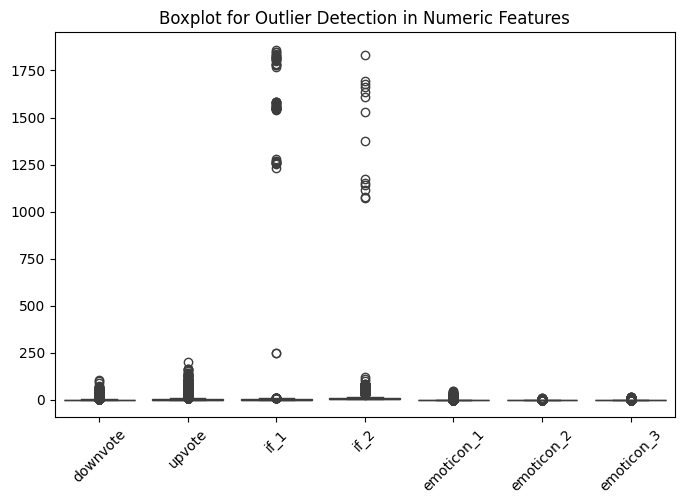

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# numeric columns in the dataset
num_cols = ['downvote', 'upvote', 'if_1', 'if_2', 'emoticon_1', 'emoticon_2', 'emoticon_3']
plt.figure(figsize=(8,5))
sns.boxplot(data=df[num_cols])
plt.title('Boxplot for Outlier Detection in Numeric Features')
plt.xticks(rotation=45)
plt.show()

##### From this boxplot we can observe that
* downvote, upvote have compact distributions with few scattered outliers.
* if_1 and if_2 have very large outlier compared to other features.
* emoticon features have fewer values but still show some variation.
* most  values are concentrated near zero, indicating right-skewd distributions.

## Looking at the correlection among various features present in the dataset

In [80]:
n_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[n_cols].corr()
corr

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,label
post_id,1.000000,0.034567,0.012501,0.049622,-0.019455,0.065511,-0.000977,0.010235,-0.010910,0.022063
emoticon_1,0.034567,1.000000,0.092087,0.144864,0.128124,0.177236,-0.002624,-0.004116,-0.005887,-0.003218
emoticon_2,0.012501,0.092087,1.000000,0.140236,0.081580,0.169366,0.001741,0.003919,0.000235,0.021597
emoticon_3,0.049622,0.144864,0.140236,1.000000,0.170662,0.371039,-0.000514,0.007191,-0.001087,0.027273
upvote,-0.019455,0.128124,0.081580,0.170662,1.000000,0.314557,-0.001654,-0.000674,0.002080,0.040181
downvote,0.065511,0.177236,0.169366,0.371039,0.314557,1.000000,0.000354,0.006307,-0.003465,0.044908
if_1,-0.000977,-0.002624,0.001741,-0.000514,-0.001654,0.000354,1.000000,0.008174,0.129887,0.007543
if_2,0.010235,-0.004116,0.003919,0.007191,-0.000674,0.006307,0.008174,1.000000,0.023374,0.232902
disability,-0.010910,-0.005887,0.000235,-0.001087,0.002080,-0.003465,0.129887,0.023374,1.000000,0.053809
label,0.022063,-0.003218,0.021597,0.027273,0.040181,0.044908,0.007543,0.232902,0.053809,1.000000


## Correlation Matrix of Numerical Features

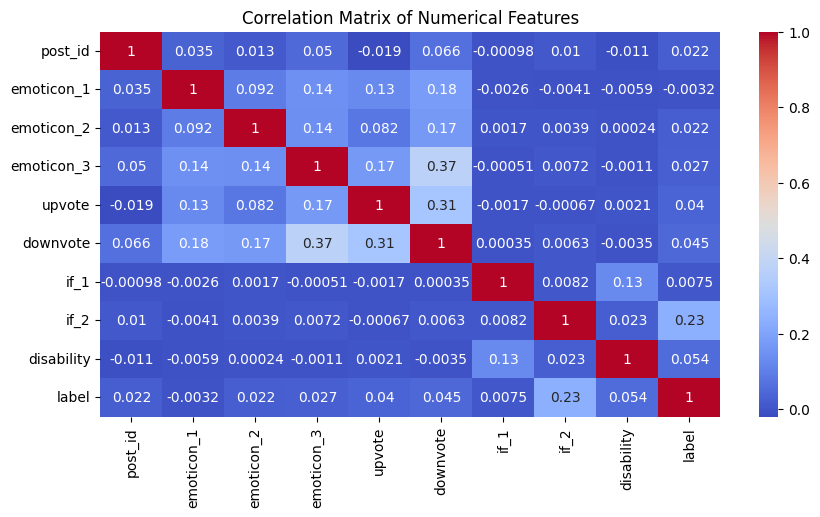

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Features")
plt.show()

##### From the above heatmap we can observe that:
* most features are weekly correlated.
* upvote and downvote has some moderate positive correlation(~0.31)
* emoticon_3 has some positive correlation with downvote(~0.37)
* if_2 shows some correlation with the target label (~0.23)
  

# Visualizations

## Mean Value of Numeric Features

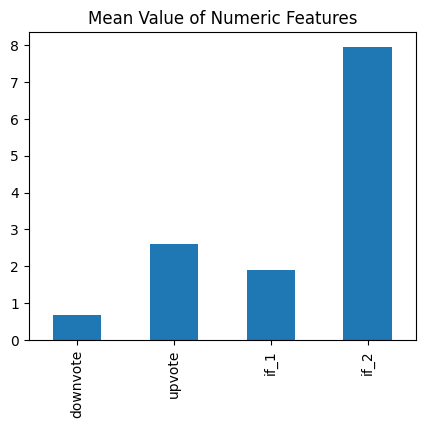

In [82]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))
df[['downvote', 'upvote', 'if_1', 'if_2']].mean().plot(kind='bar')
plt.title("Mean Value of Numeric Features")
plt.show()

The bar graph shows the average values of the selected numerical features.
* if_2 has the highest mean value among all features
* upvote and if_1 have moderate average value
* downvote has the lowest mean value

## Scatter Plot: Comment Length vs upvote

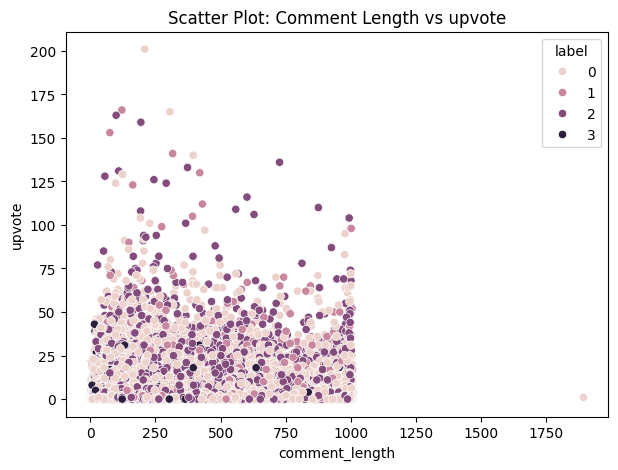

In [83]:
df['comment_length'] = df['comment'].str.len()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='comment_length',
    y='upvote',
    hue='label',
)
plt.title("Scatter Plot: Comment Length vs upvote")
plt.show()


##### The above scatter plot shows the relationship between comment length and number of upvotes.
* No strong correlation can be seen between comment length and upvotes.
* Most comments have low to moderate upvote counts.
* Most comments recieve low engagement.
* High upvotes are scattered across different comment lengths.
* 
There is no clear seperation of labels based on comment length.

## Histogram for different numerial features

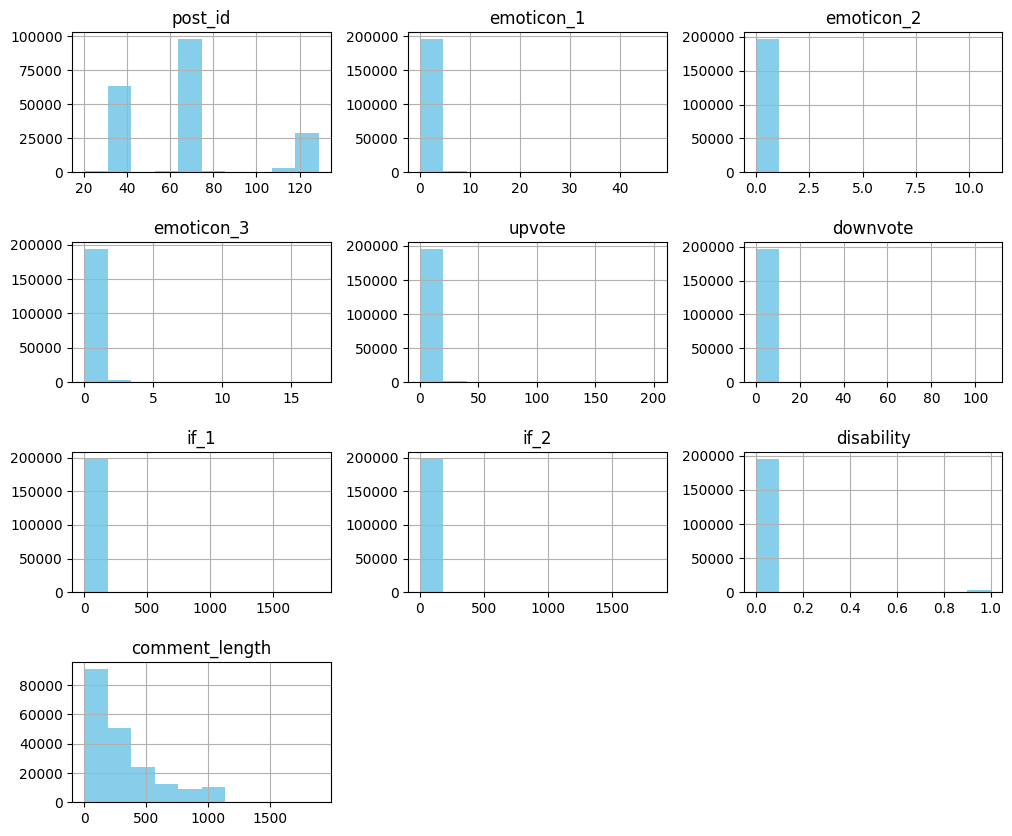

In [84]:
num = df.select_dtypes(include=['int64', 'float64']).drop(columns=['label'])
num.hist(bins=10, figsize=(12,10), color='skyblue')
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

##### We have plotted histogram for different numerial features, it will help us to analyze the distribution of these features. 
##### Most numerical features are highly right skewed.

## Pie Chart for Target Variable(label)

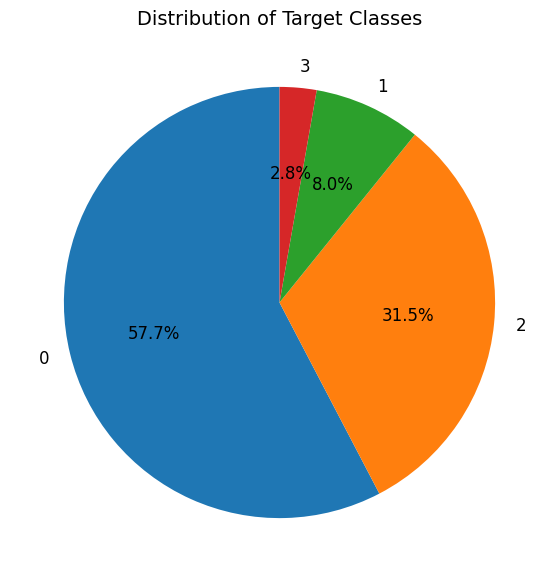

In [85]:
label_count = df['label'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(label_count, labels=label_count.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize':12})
plt.title("Distribution of Target Classes", fontsize=14)
plt.show()

From the above pie chart we can observe that :
* Class 0 represents the majority of the dataset (57.7%).
* Class 2 is the second largest class (31.5%)
* class 1 contains a smaller portion (8.0%)
* class 3 is the smallest class (2.8%)

# Feature Engineering and Data Type Conversion.

In [86]:
df['comment_length'] = df['comment'].str.len()
df['question_count'] = df['comment'].apply(lambda x: x.count('?'))
df['exclaimation_count'] = df['comment'].str.count('!')

df['created_date'] = pd.to_datetime(df['created_date'])
df['posted_day'] = df['created_date'].dt.dayofweek
df['posted_hour'] = df['created_date'].dt.hour
df['month'] = df['created_date'].dt.month
df['year'] = df['created_date'].dt.year
df.drop(columns=['created_date'], inplace=True)

test_df['comment_length'] = test_df['comment'].str.len()
test_df['question_count'] = test_df['comment'].apply(lambda x: x.count('?'))
test_df['exclaimation_count'] = test_df['comment'].str.count('!')

test_df['created_date'] = pd.to_datetime(test_df['created_date'])
test_df['posted_day'] = test_df['created_date'].dt.dayofweek
test_df['posted_hour'] = test_df['created_date'].dt.hour
test_df['month'] = test_df['created_date'].dt.month
test_df['year'] = test_df['created_date'].dt.year
test_df.drop(columns=['created_date'], inplace=True)

* The comment_lenght feature was created to capture the total number of characters in each comment.This helps to get the overall size of the text.
* The question_count feature was created to get the count of the number of question marks(?) in each comment.This can reflect questioning or intrrogative tone.
* The exclaimation_count was created to get the count of the number of exclaimation marks(!) in each comment.This can reflect emotional strong expressions in the text.
  
The created_date column was converted to datetime format to extract the following useful feature:
* posted_day, posted_hour, month, year
After extracting these features, the original created_date column was dropped.

The same preprocessing steps were applied to both the training and test datasets to maintain consistency.

# Drop the POST ID columns

In [87]:
df.drop(columns=['post_id'], inplace=True)
test_df.drop(columns=['post_id'], inplace=True)

The post_id column was removed from the dataset as it acts as an identifier and does not provide useful information for model training.

# Feature and Target Seperation

In [88]:
X = df.drop(['label'], axis=1)
y = df['label']

The dataset was divided into features(X) and target variable(y)
* X contains all input columns
* y contains the label column wich is the target variable

In [89]:
labels = list(map(int, sorted(y.unique())))

# Separating Numerical and Categorical Features

In [90]:
num_cols = X.select_dtypes(include=['int64','float64']).columns
text_col = 'comment'
cat_cols = X.select_dtypes(include=['object']).columns.difference([text_col])
print(num_cols)
print(cat_cols)
print([text_col])

Index(['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1',
       'if_2', 'disability', 'comment_length', 'question_count',
       'exclaimation_count'],
      dtype='object')
Index(['gender', 'race', 'religion'], dtype='object')
['comment']


# Data Splitting

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

* The dataset was was split into training (80%) and validation (20%) sets using train_test_split.
* Stratification  was applied to maintain the same class distribution in both sets.
* A random_state of 42 was set to ensure reproducibility of the split.

# Scale Numerical features and Encode Categorical features

In [92]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

In [93]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('absolute', FunctionTransformer(np.abs))
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

text_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='')),
    ('flatten', FunctionTransformer(lambda x: x.ravel(), validate=False)),
    ('tv',  TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=50000))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
    ('text', text_pipe, [text_col])
], remainder='drop')
X_train_pro = preprocessor.fit_transform(X_train)
X_val_pro = preprocessor.transform(X_val)

Seperate preprocessing pipelines were created for numerical, categorical and text features.
* Numerical features were imputed with median values and also absolute value function was applied to ensure that no negative values remain in the dataset.
* Categorical features were inputed with the most frequent value and also One-hot encoding was applied to convert categorical variables into numerical format. handle_unknown='ignore' ensures that unseen categories in the validation test data do not cause errors.
* The text column was flattened to a one-dimensional format for vectorization.
TfidfVectorizer was applied using  unigrams and bigrams (these were used to preserve contextual information), keeping max_features=50000. min_df = 2 was used so that extremely rare terms appearing only once are ignored. Here, since the dataset contains a large number of comments so  max_features=50000 was kept to capture a wide range of important words and word combinations.
* A ColumnTransformer was used to combine these pipelines and apply the appropriate transformation to each feature type.
* The preprocessing pipeline was fitted on the training data and then applied to both training and validation datasets to generate the processed feature matrices.

# Entire Pipeline

In [94]:
from sklearn import set_config
set_config(display='diagram')

entire_pipeline = Pipeline(steps=[('Scaling', num_pipe),
                                  ('Encoding', cat_pipe),
                                  ('Vectorizer', text_pipe),
                                 ('Preprocessor', preprocessor)])
entire_pipeline


Pipeline(steps=[('Scaling',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('absolute',
                                  FunctionTransformer(func=<ufunc 'absolute'>))])),
                ('Encoding',
                 Pipeline(steps=[('imputer',
                                  SimpleImputer(strategy='most_frequent')),
                                 ('onehot',
                                  OneHotEncoder(handle_unknown='ignore'))])),
                ('Vectorizer',
                 Pipeline(steps=[('imputer',
                                  SimpleImputer(fill_value='',...
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'race', 'religion'], dtype='object')),
                                                 ('text',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='',
                                                                                 strategy='constant')),
                                                                  ('flatten',
                                                                   FunctionTransformer(func=<function <lambda> at 0x78f8b654a5c0>)),
                                                                  ('tv',
                                                                   TfidfVectorizer(max_features=50000,
                                                                                   min_df=2,
                                                                                   ngram_range=(1,
                                                                                                2)))]),
                                                  ['comment'])]))])

# Model Training

In [95]:
from sklearn.metrics import f1_score, accuracy_score

## DummyClassifier

In [96]:
from sklearn.dummy import DummyClassifier
dmy_model = DummyClassifier(strategy="most_frequent")
dmy_model.fit(X_train_pro, y_train)
dmy_val_pred = dmy_model.predict(X_val_pro)
dmy_acc = accuracy_score(y_val, dmy_val_pred)
dmy_f1 = f1_score(y_val, dmy_val_pred, average='macro')
print("accuracy_score = ", dmy_acc)
print("f1_score = ", dmy_f1)

accuracy_score =  0.5766414141414141
f1_score =  0.18287018499239208


## LogisticRegression

In [97]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(C=4, max_iter= 1000, class_weight= 'balanced', tol= 0.0001, solver= 'newton-cg', penalty= 'l2', random_state=42, n_jobs=-1)
lr_model.fit(X_train_pro, y_train) 
lr_val_pred = lr_model.predict(X_val_pro)
lr_acc = accuracy_score(y_val, lr_val_pred)
lr_f1 = f1_score(y_val, lr_val_pred, average='macro')
print("accuracy_score = ", lr_acc)
print("f1_score = ", lr_f1)

accuracy_score =  0.8987878787878788
f1_score =  0.797845611411218


### Confusion Matrix

In [98]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, lr_val_pred, labels=labels)
print(cm)

[[21197   400  1041   197]
 [   31  2595   478    79]
 [  366   748 11019   355]
 [   30    77   206   781]]


## LGBMClassifier

In [99]:
from lightgbm import LGBMClassifier
lgb_model = LGBMClassifier(n_estimators=680, learning_rate=0.05, max_depth=-1, num_leaves=115, objective='multiclass', random_state=42, n_jobs=-1)
lgb_model.fit(X_train_pro, y_train)
lgb_val_pred = lgb_model.predict(X_val_pro)
lgb_acc = accuracy_score(y_val, lgb_val_pred)
lgb_f1 = f1_score(y_val, lgb_val_pred, average='macro')
print("accuracy_score = ", lgb_acc)
print("f1_score = ", lgb_f1)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 77.644746 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1932691
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 49915
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217
accuracy_score =  0.9158585858585858
f1_score =  0.8145859572268646


### Confusion Matrix

In [100]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, lgb_val_pred, labels=labels)
print(cm)

[[21686   150   945    54]
 [   61  2494   597    31]
 [  416   466 11509    97]
 [   50    72   393   579]]


## LinearSVC

In [101]:
from sklearn.svm import LinearSVC
svc_model = LinearSVC(max_iter=5000, C=4, loss='squared_hinge', class_weight='balanced', random_state=42)
svc_model.fit(X_train_pro, y_train)
svc_val_pred = svc_model.predict(X_val_pro)
svc_acc = accuracy_score(y_val, svc_val_pred)
svc_f1 = f1_score(y_val, svc_val_pred, average='macro')
print("accuracy_score = ", svc_acc)
print("f1_score = ", svc_f1)

accuracy_score =  0.7919444444444445
f1_score =  0.6893362733028056


### Confusion Matrix

In [102]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, svc_val_pred, labels=labels)
print(cm)

[[19744   746  2010   335]
 [  580  2262   287    54]
 [ 2947   560  8799   182]
 [  382    62    94   556]]


## RandomForestClassifier

In [103]:
# from sklearn.ensemble import RandomForestClassifier
# rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2306, n_jobs=-1)
# rf_model.fit(X_train_pro, y_train)
# rf_val_pred = rf_model.predict(X_val_pro)
# rf_acc = accuracy_score(y_val, rf_val_pred)
# rf_f1 = f1_score(y_val, rf_val_pred, average='macro')
# print("accuracy_score = ", rf_acc)
# print("f1_score = ", rf_f1)

* accuracy_score =  0.5771212121212121
* f1_score =  0.1836882970561742

## MLPClassifier

In [104]:
# from sklearn.neural_network import MLPClassifier
# mlp_model = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation = "relu", solver = "adam", max_iter = 5, batch_size = 32, random_state = 2306)
# mlp_model.fit(X_train_pro, y_train)
# mlp_val_pred = mlp_model.predict(X_val_pro)
# mlp_acc = accuracy_score(y_val, mlp_val_pred)
# mlp_f1 = f1_score(y_val, mlp_val_pred, average='macro')
# print("accuracy_score = ", mlp_acc)
# print("f1_score = ", mlp_f1)

* accuracy_score =  0.8832323232323233
* f1_score =  0.6573544725924326

# Hyperparameter Tuning

## RandomizedSearchCV (Logistic Regression)

In [105]:
# from sklearn.model_selection import RandomizedSearchCV
# param_grid = {
#     'C':[0.01, 0.1, 0.5, 1, 2, 3, 4, 5, 10],
#     'penalty':["l1", "l2"],
#     'solver':["lbfgs", "saga", "newton-cg"],
#     'max_iter':[1000, 2000, 3000, 5000],
#     'class_weight':["None", "balanced"],
#     'tol':[1e-3, 1e-4]
# }
# rs = RandomizedSearchCV(estimator=lr_model, param_distributions=param_grid, n_iter = 10, cv = 3,scoring="f1_macro", random_state = 42, n_jobs = -1, verbose=2)
# rs.fit(X_train_pro, y_train)
# best_params = rs.best_params_
# print("Best Parameters =", best_params)

The result of this hyperprameter tuning is:
* Best Parameters = {'tol': 0.0001, 'solver': 'newton-cg', 'penalty': 'l2', 'max_iter': 1000, 'class_weight': 'balanced', 'C': 4}

## RandomizedSearchCV (LGBMClassifier)

In [106]:
# from sklearn.model_selection import RandomizedSearchCV
# param_grid = {
#     'n_estimators': [500, 600,720],
#     'learning_rate': [0.03, 0.05,0.1],
#     'num_leaves': [63,115,127]
# }
# rs = RandomizedSearchCV(estimator=lgb_model, param_distributions=param_grid, n_iter = 5,cv = 3, scoring="f1_macro", random_state = 42, n_jobs = -1, verbose=2)
# rs.fit(X_train_pro, y_train)
# best_params = rs.best_params_
# print("Best Parameters =", best_params)

The result of this hyperprameter tuning is:
* Best Parameters = {'n_estimators': 600, 'learning_rate': 0.05, 'num_leaves': 115}

## GridSearchCV (LinearSVC)

In [107]:
#  from sklearn.model_selection import GridSearchCV
# param_grid = {
#     'C':[0.01, 0.1, 1, 5],
#     'loss':['hinge', 'squared_hinge'],
#     'max_iter':[1000, 2000]
# }

# grid = GridSearchCV(svc_model, param_grid, cv=3, n_jobs=-1, scoring='f1_macro', verbose=2)
# grid.fit(X_train_pro, y_train)

# print("Best Parameters =", grid.best_params_)
# print("Best f1_score =", grid.best_score_)

The result of this hyperprameter tuning is:
* Best Parameters = {'C': 1, 'loss': 'squared_hinge', 'max_iter': 1000}
* Best f1_score = 0.6644258320517032

## Comparing different models

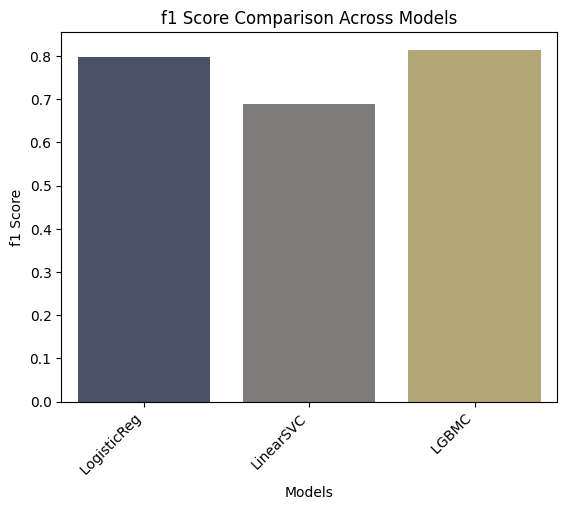

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# putting model names and scores together in a dataframe
results_df = pd.DataFrame({
    'Model': [' LogisticReg', 'LinearSVC', ' LGBMC'],
    'f1_Score': [lr_f1, svc_f1, lgb_f1]
})

# creating the barplot
sns.barplot(x='Model', y='f1_Score', data=results_df, palette='cividis')
plt.xlabel('Models')
plt.ylabel('f1 Score')
plt.xticks(rotation=45, ha='right')
plt.title('f1 Score Comparison Across Models')
plt.show()

Here,
The macro F1 score of the three models was compared and we can see that,
* LGBMClassifier achieved the highest F1 score among the other models.
* Logistic Regression performed better than LinearSVC but lower than LGBMClassifier.
* LinearSVC showed the lowed performance among the three models.


## Assigning the best model

In [109]:
best_model = lgb_model

In [110]:
X_test = test_df

# Final Model Training

In [111]:
X_pro = preprocessor.fit_transform(X)
X_test_pro = preprocessor.transform(X_test)
best_model.fit(X_pro, y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 114.556838 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2281799
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 49999
[LightGBM] [Info] Start training from score -0.550552
[LightGBM] [Info] Start training from score -2.520816
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589171


LGBMClassifier(learning_rate=0.05, n_estimators=680, n_jobs=-1, num_leaves=115,
               objective='multiclass', random_state=42)

* The preprocessing pipeline was applied to the full dataset.
* The transformed features were stored in X_pro.
* The same transformation was applied to the test dataset.
* The best model was trained on the entire dataset. 

# Submission

In [112]:
y_pred = best_model.predict(X_test_pro)
submission = pd.DataFrame({'ID': range(1, X_test_pro.shape[0]+1), 'label': y_pred})
submission.to_csv('submission.csv', index=False)